# Classification for iris data: load_iris()

x.shape (150, 4)
classes: [0 1 2]
2
y_train_cat: [[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,675 (18.26 KB)

 Trainable params: 4,675 (18.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5500 - loss: 1.0669 - val_accuracy: 0.6667 - val_loss: 0.9487
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8083 - loss: 0.8685 - val_accuracy: 0.7667 - val_loss: 0.7853
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8167 - loss: 0.7122 - val_accuracy: 0.7667 - val_loss: 0.6633
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8083 - loss: 0.5904 - val_accuracy: 0.7667 - val_loss: 0.5726
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8167 - loss: 0.5055 - val_accuracy: 0.7667 - val_loss: 0.5063
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8417 - loss: 0.4401 - val_accuracy: 0.7667 - val_loss: 0.4560
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8500 - loss: 0.3905 - val_accuracy: 0.7333 - val_loss: 0.4162
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8667 - loss: 0.3511 - val_accuracy: 0.7667 - val_loss: 0.3852

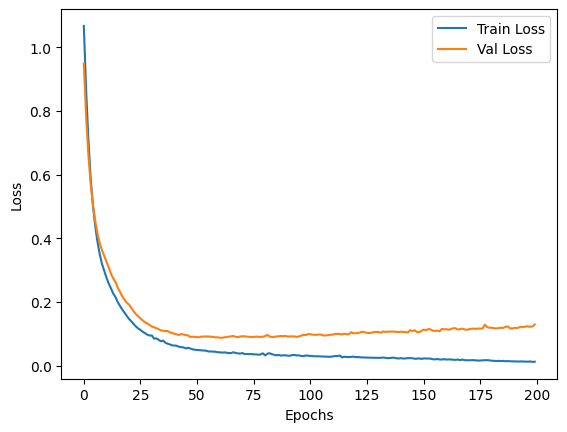

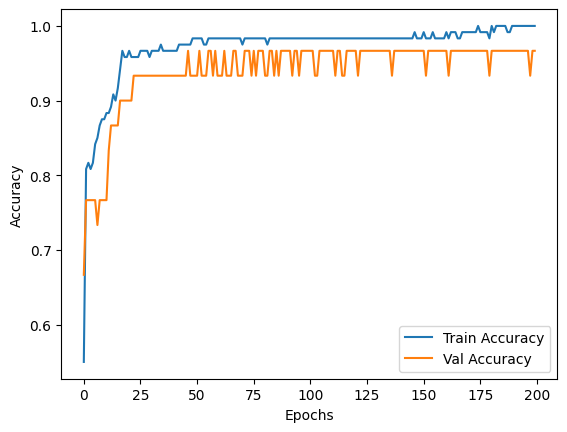

Training Accuracy: 1.0000
Validation Accuracy: 0.9667
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
True labels:      [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]
Predicted labels: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


In [10]:
# -*- coding: utf-8 -*-
"""
Created on Wed Sep 24 21:10:09 2025

@author: WUG2SI
"""

from tensorflow import keras
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Daten laden
# -----------------------------
iris = load_iris()
X = iris.data   # 4 Features
y = iris.target # Labels 0,1,2
print("x.shape", X.shape)


classes = np.unique(y)
print("classes:", classes)
print(y.max())
print("===========")


# Train/Test Split
x_train, x_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Skalierung (StandardScaler oder MinMaxScaler möglich)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)


                    
# Labels in One-Hot-Encoding für categorical_crossentropy
y_train_cat = keras.utils.to_categorical(y_train, num_classes=3)
y_val_cat = keras.utils.to_categorical(y_val, num_classes=3)
print("y_train_cat:", y_train_cat[0:10])
# -----------------------------
# Modell erstellen
# -----------------------------
model = keras.models.Sequential()
model.add(keras.layers.Input(shape=(x_train.shape[1],)))
model.add(keras.layers.Dense(64, activation="relu"))
model.add(keras.layers.Dense(64, activation="relu"))
model.add(keras.layers.Dense(3, activation="softmax"))  # 3 Klassen

model.summary()

# -----------------------------
# Kompilieren
# -----------------------------
model.compile(loss="categorical_crossentropy",
              optimizer=keras.optimizers.Adam(learning_rate=0.001),
              metrics=["accuracy"])

# -----------------------------
# Training
# -----------------------------
history = model.fit(x_train, y_train_cat,
                    validation_data=(x_val, y_val_cat),
                    epochs=200,
                    batch_size=16,
                    verbose=1)  # 0: kein Spam im Output; 1: ja

print(history.history.keys())

# -----------------------------
# Lernkurven plotten
# -----------------------------
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# -----------------------------
# Evaluation
# -----------------------------
train_acc = model.evaluate(x_train, y_train_cat, verbose=0)[1]
val_acc = model.evaluate(x_val, y_val_cat, verbose=0)[1]
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

# -----------------------------
# Prediction auf Validierungsdaten
# -----------------------------
y_pred_proba = model.predict(x_val)
y_pred = np.argmax(y_pred_proba, axis=1)

print("True labels:     ", y_val[:30])
print("Predicted labels:", y_pred[:30])



    